In [1]:
%pip install matplotlib
%pip install pandas
%pip install scikit-learn
%pip install numpy 
%pip install sympy
%pip install tensorflow
%pip install keras


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 21.1 MB/s  0:00:14m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sympy.solvers.solveset import linsolve
from sympy import symbols


# Data Loading and Exploration

I begin the project by importing the necessary libraries

In [3]:
plt.style.use('ggplot')

In [20]:
#Had to sort the data as it was not in order of x values, which is important for plotting and training the model

train_data = pd.read_csv('train.csv')
train_data.sort_values('x', inplace=True)

x_train = train_data.x.to_numpy()
y_train = train_data.y.to_numpy()

validation_dataset = pd.read_csv('val.csv')
validation_dataset.sort_values('x', inplace=True)

x_val = validation_dataset.x.to_numpy()
y_val = validation_dataset.y.to_numpy()


The data seems to fit a polynomial distribution with some noise as can be seen from the scatter plot below.
Validation dataset less clustered, due to less data (4x less). 
Both datasets have very similar shape.


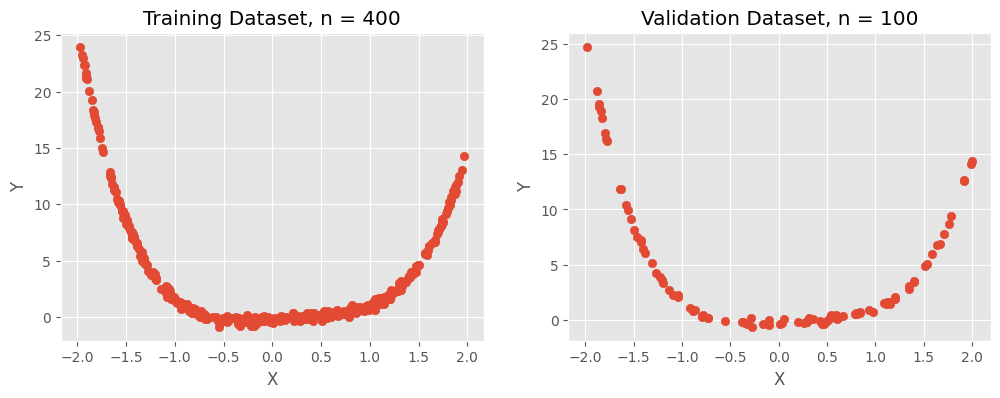

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].scatter(x_train, y_train)
axs[0].set_title(f'Training Dataset, n = {x_train.size}')
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')

axs[1].scatter(x_val, y_val)
axs[1].set_title(f'Validation Dataset, n = {x_val.size}')
axs[1].set_xlabel('X')
axs[1].set_ylabel('Y')

# plt.tight_layout()

plt.show()

## Polynomial Regression

In [6]:
#We are told the polynomial is of degree 4 
poly = PolynomialFeatures(degree=4, include_bias=False)
poly_features = poly.fit_transform(x_train.reshape(-1, 1))

In [7]:
# poly.transform(x.reshape(-1, 1))

In [8]:
from sklearn.linear_model import LinearRegression

poly_reg_model = LinearRegression()
poly_reg_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
params = poly_reg_model.fit(poly_features, y_train)

y_predicted = poly_reg_model.predict(poly_features)
# print(y_predicted[:10])
# print(y[:10])


In [10]:
d, c, b, a = params.coef_
print(a, b, c, d)
intercept = params.intercept_
print(params.intercept_)

1.2053934318561343 -0.8036620332156275 0.28989803950813664 0.5075934645790964
-0.21463817306569455


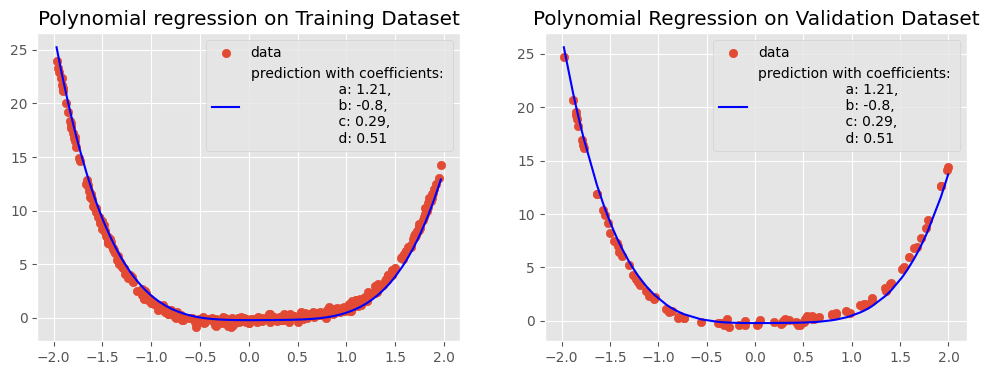

Mean Squared Error on Training Dataset: 0.37636243729848007
Mean Squared Error on Validation Dataset: 0.3553913903090921


In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

#----------------------------------------------------------------------------------------------------------------------------
#test_data_pred
train_data_pred = [a*x_i**4 + b*x_i**3 + c*x_i**2 + intercept for x_i in x_train]

# plt.scatter(x, y)
a2, b2, c2, d2 = [round(i, 2) for i in [a, b, c, d]]
data = axs[0].scatter(x_train, y_train, label='data')
prediction = axs[0].plot(x_train, train_data_pred, c='blue', label=f'''prediction with coefficients: 
                    a: {a2},
                    b: {b2},
                    c: {c2},
                    d: {d2}''')
axs[0].set_title('Polynomial regression on Training Dataset')
axs[0].legend()

#----------------------------------------------------------------------------------------------------------------------------
#validation_data_pred


validation_data_pred = [a*x_i**4 + b*x_i**3 + c*x_i**2 + intercept for x_i in x_val]
axs[1].scatter(x_val, y_val, label='data')
axs[1].plot(x_val, 
    validation_data_pred,
    c='blue', label=f'''prediction with coefficients: 
                    a: {a2},
                    b: {b2},
                    c: {c2},
                    d: {d2}''')
axs[1].legend()


axs[1].set_title('Polynomial Regression on Validation Dataset')

plt.show()

from sklearn.metrics import mean_squared_error

polynomial_mse_train = mean_squared_error(train_data_pred, y_train)
polynomial_mse_val = mean_squared_error(validation_data_pred, y_val)

print(f'Mean Squared Error on Training Dataset: {polynomial_mse_train}')
print(f'Mean Squared Error on Validation Dataset: {polynomial_mse_val}')



## MLP

In [14]:
import tensorflow as tf
from tensorflow import keras

In [38]:
X, y = np.array(x_train, dtype='float32'), y_train

type(X[0])

numpy.float32

In [31]:
class Model(tf.Module):

    def __init__(self):
        # Randomly generated weights
        init_weights = tf.random.uniform(shape=[5], minval=-10, maxval=10, seed=11)
        # Initialize weights
        self.weight_a = tf.Variable(init_weights[0])
        self.weight_b = tf.Variable(init_weights[1])
        self.weight_c = tf.Variable(init_weights[2])
        self.weight_d = tf.Variable(init_weights[3])
        self.bias = tf.Variable(init_weights[4])

    @tf.function
    def __call__(self, x):
        # Cubic Model : a * x^3 + b * x^2 + c * x + d
        return (self.weight_a * x**4) + (self.weight_b * x**3) + (self.weight_c * x**2) + (self.weight_d * x) + self.bias 

In [32]:
# Intialise Model
model = Model()


In [56]:
def mse(y, y_pred):
    return tf.reduce_mean(tf.square(y - y_pred))

epochs = 3000
learning_rate = 0.01
losses = []

# Training Loop
for epoch in range(epochs):
    with tf.GradientTape() as tape:
        y_pred = model(X)
        loss = mse(y, y_pred)
    grads = tape.gradient(loss, model.variables) # find gradients of loss w.r.t weights and bias i.e., partial differentiation

    # Update weights and bias
    for g,v in zip(grads, model.variables):
        v.assign_sub(learning_rate * g)
    # Loss per Epoch
    loss = mse(y, model(X))
    losses.append(loss)
    if epoch % 25 == 0:
        print(f"Epoch: {epoch}, Loss: {loss.numpy():.4f}")
        print("     >> ", model.variables)

Epoch: 0, Loss: 1.5420
     >>  (<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=1.5411512851715088>, <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=2.10577130317688>, <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=-0.369465708732605>, <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=-3.0039610862731934>, <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=-0.6595773100852966>)
Epoch: 25, Loss: 1.4002
     >>  (<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=1.4712259769439697>, <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=2.068434000015259>, <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=-0.4060375988483429>, <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=-2.868518829345703>, <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=-0.5620679259300232>)


Epoch: 50, Loss: 1.2733
     >>  (<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=1.4033607244491577>, <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=2.0328497886657715>, <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=-0.43952780961990356>, <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=-2.7389633655548096>, <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=-0.47274231910705566>)
Epoch: 75, Loss: 1.1594
     >>  (<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=1.337735891342163>, <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=1.9988716840744019>, <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=-0.4701971709728241>, <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=-2.614935874938965>, <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=-0.3909088373184204>)
Epoch: 100, Loss: 1.0572
     >>  (<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=1.2744413614273071>, <tf.Variable 'Variable:0' shape=() dtype=flo

In [57]:
a = model.weight_a
b = model.weight_b
c = model.weight_c
d = model.weight_d
e = model.bias


In [58]:
x_range = np.linspace(min(x_train), max(x_train), len(x_train))
y_tf_pred = [a*x_i**4 + b*x_i**3 + c*x_i**2 + d*x_i + e for x_i in x_range]

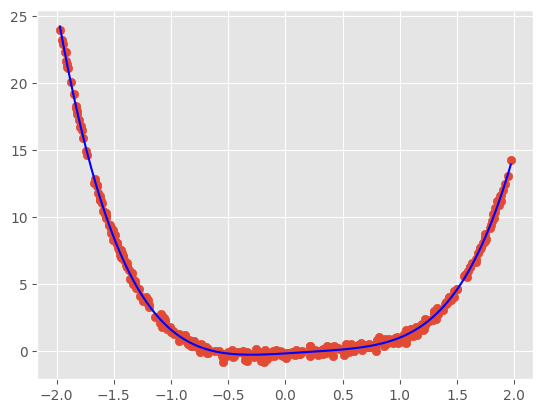

In [59]:
plt.plot(x_range, y_tf_pred, c='blue')
plt.scatter(x_train, y_train, label='data')